# RTTM to simple

In [10]:
example2="""
SPEAKER azisu 1 7.960000 5.720000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 138.600000 13.840000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 156.880000 6.480000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 169.840000 4.920000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 180.160000 1.960000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 95.440000 1.000000 <NA> <NA> spk01 <NA> <NA>
SPEAKER azisu 1 102.000000 36.600000 <NA> <NA> spk01 <NA> <NA>
SPEAKER azisu 1 150.760000 7.360000 <NA> <NA> spk01 <NA> <NA>
SPEAKER azisu 1 159.160000 12.560000 <NA> <NA> spk01 <NA> <NA>
SPEAKER azisu 1 172.480000 2.800000 <NA> <NA> spk01 <NA> <NA>
SPEAKER azisu 1 51.200000 2.240000 <NA> <NA> spk02 <NA> <NA>
SPEAKER azisu 1 36.960000 7.360000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 101.760000 1.200000 <NA> <NA> spk02 <NA> <NA>
SPEAKER azisu 1 190.840000 1.640000 <NA> <NA> spk02 <NA> <NA>
SPEAKER azisu 1 0.520000 8.120000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 9.440000 1.320000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 12.800000 24.200000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 43.560000 13.720000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 74.160000 0.520000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 174.480000 3.240000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 177.880000 16.240000 <NA> <NA> spk03 <NA> <NA>
SPEAKER azisu 1 45.560000 1.600000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 53.880000 1.080000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 57.480000 30.360000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 88.000000 14.280000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 109.880000 2.120000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 123.960000 0.880000 <NA> <NA> spk00 <NA> <NA>
SPEAKER azisu 1 125.200000 0.440000 <NA> <NA> spk00 <NA> <NA>
"""

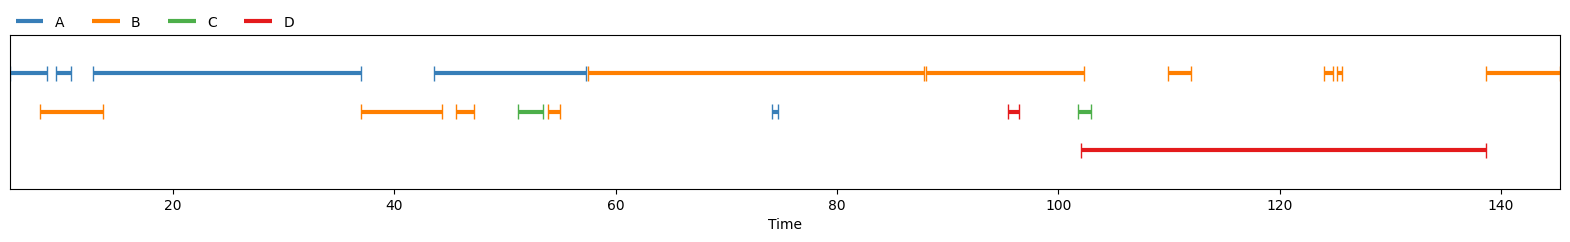

In [23]:
def convert_rttm(input_text):
    lines = input_text.strip().split('\n')
    speaker_map = {}
    current_speaker = 'A'
    segments = []

    for line in lines:
        parts = line.split()
        start_time = float(parts[3])
        duration = float(parts[4])
        speaker_label = parts[7]
        segments.append([start_time, duration, speaker_label])
    
    segments = sorted(segments, key=lambda x: x[0])

    for seg in segments:
        if seg[-1] not in speaker_map:
            speaker_map[seg[-1]] = current_speaker
            current_speaker = chr(ord(current_speaker) + 1)
        seg[-1] = speaker_map[seg[-1]]
        
    return segments


sorted_segments = convert_and_sort_diarization(example2)
from pyannote.core import Segment, Annotation

ann = Annotation()
for i in sorted_segments:
    ann[Segment(i[0],i[0]+i[1])] = i[2]
ann

In [27]:
print("\n".join([str(x) for x in sorted_segments]))

[0.52, 8.12, 'A']
[7.96, 5.72, 'B']
[9.44, 1.32, 'A']
[12.8, 24.2, 'A']
[36.96, 7.36, 'B']
[43.56, 13.72, 'A']
[45.56, 1.6, 'B']
[51.2, 2.24, 'C']
[53.88, 1.08, 'B']
[57.48, 30.36, 'B']
[74.16, 0.52, 'A']
[88.0, 14.28, 'B']
[95.44, 1.0, 'D']
[101.76, 1.2, 'C']
[102.0, 36.6, 'D']
[109.88, 2.12, 'B']
[123.96, 0.88, 'B']
[125.2, 0.44, 'B']
[138.6, 13.84, 'B']
[150.76, 7.36, 'D']
[156.88, 6.48, 'B']
[159.16, 12.56, 'D']
[169.84, 4.92, 'B']
[172.48, 2.8, 'D']
[174.48, 3.24, 'A']
[177.88, 16.24, 'A']
[180.16, 1.96, 'B']
[190.84, 1.64, 'C']


In [ ]:
[0.52, 8.12, 'A'] "Hey you are really annoying me"
[7.96, 5.72, 'B'] "Fuck off you don't knnowwh atyou're talking about"
[9.44, 1.32, 'A']
[12.8, 24.2, 'A']